
# Laboratorio 6 — Transfer Learning y Fine-Tuning con CIFAR-10



In [1]:

# 0. Dependencias
# Si hace falta en Colab/Jupyter:
# !pip install -q torch torchvision scikit-learn pandas matplotlib tqdm fvcore

import os
import gc
import time
import copy
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms, models
from torchvision.models import VGG16_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from tqdm.auto import tqdm

try:
    from fvcore.nn import FlopCountAnalysis
    FVCORE_AVAILABLE = True
except Exception:
    FVCORE_AVAILABLE = False
    print("fvcore no está disponible; FLOPs se reportarán como NaN.")

print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("Python:", platform.python_version())


fvcore no está disponible; FLOPs se reportarán como NaN.
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Python: 3.13.15


In [2]:
# 1. Configuración general y reproducibilidad

SEED = 2026
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./resultados_lab6")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# La guía permite usar 112x112 o 128x128 para VGG-16.
# 112x112 reduce aproximadamente 23% los píxeles respecto a 128x128.
VGG_IMAGE_SIZE = 112

BATCH_SIZE_CNN = 128
BATCH_SIZE_VGG = 64

# Para la entrega final dejar en False.
FAST_DEV_RUN = False

NUM_WORKERS = 0 if os.name == "nt" else 2
PIN_MEMORY = torch.cuda.is_available()

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# Mixed precision solo se activa en CUDA.
USE_AMP = (device.type == "cuda")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

        # Más rápido en GPU para tamaños de entrada fijos.
        torch.backends.cudnn.benchmark = True

set_seed()

print("Dispositivo:", device)
print("CUDA disponible:", torch.cuda.is_available())
print("Mixed precision:", USE_AMP)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CPU:", platform.processor() or platform.machine())
    print()
    print("ADVERTENCIA: VGG-16 será MUY lento en CPU.")
    print("Para las 9 iteraciones se recomienda ejecutar este notebook con GPU.")


Dispositivo: cuda
CUDA disponible: True
Mixed precision: True
GPU: Tesla T4



## 2. Carga y exploración de CIFAR-10

Primero se carga el dataset sin normalización para inspeccionar su estructura y calcular las estadísticas de los canales.


In [3]:

# 2.1 Carga inicial

train_raw = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True
)

test_raw = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True
)

class_names = train_raw.classes
num_classes = len(class_names)

print("Clases:", class_names)
print("Train:", len(train_raw))
print("Test :", len(test_raw))
print("Número de clases:", num_classes)
print("Resolución:", train_raw[0][0].size)
print("Modo:", train_raw[0][0].mode)


100%|██████████| 170M/170M [01:57<00:00, 1.45MB/s]


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 50000
Test : 10000
Número de clases: 10
Resolución: (32, 32)
Modo: RGB


,clase_id,clase,cantidad,porcentaje
0,0,airplane,5000,10.0
1,1,automobile,5000,10.0
2,2,bird,5000,10.0
3,3,cat,5000,10.0
4,4,deer,5000,10.0
5,5,dog,5000,10.0
6,6,frog,5000,10.0
7,7,horse,5000,10.0
8,8,ship,5000,10.0
9,9,truck,5000,10.0


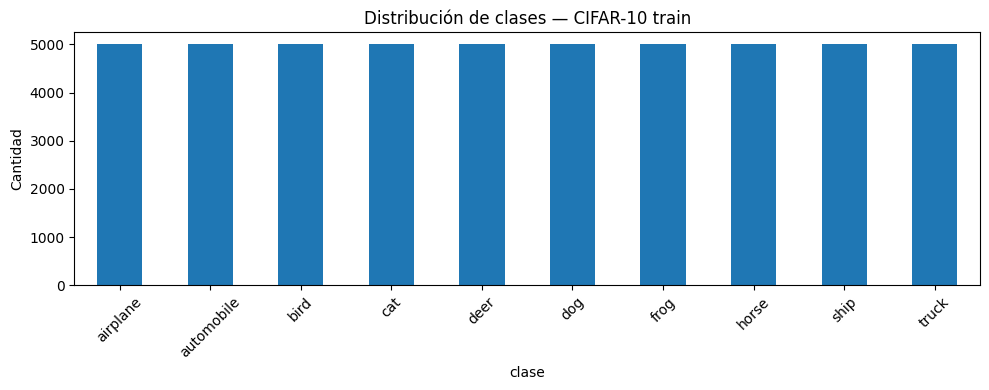

In [4]:

# 2.2 Balance de clases

targets = np.array(train_raw.targets)
class_counts = np.bincount(targets, minlength=num_classes)

balance_df = pd.DataFrame({
    "clase_id": np.arange(num_classes),
    "clase": class_names,
    "cantidad": class_counts,
    "porcentaje": class_counts / len(train_raw) * 100
})

display(balance_df)

ax = balance_df.plot(
    x="clase",
    y="cantidad",
    kind="bar",
    legend=False,
    figsize=(10, 4),
    title="Distribución de clases — CIFAR-10 train"
)
ax.set_ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:

# 2.3 Media y desviación estándar por canal

stats_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=transforms.ToTensor()
)

stats_loader = DataLoader(
    stats_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=NUM_WORKERS
)

channel_sum = torch.zeros(3)
channel_sum_sq = torch.zeros(3)
pixel_count = 0

for images, _ in tqdm(stats_loader, desc="Estadísticas"):
    b, c, h, w = images.shape
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_sum_sq += (images ** 2).sum(dim=(0, 2, 3))
    pixel_count += b * h * w

cifar_mean = channel_sum / pixel_count
cifar_std = torch.sqrt(channel_sum_sq / pixel_count - cifar_mean ** 2)

imagenet_mean = torch.tensor([0.485, 0.456, 0.406])
imagenet_std = torch.tensor([0.229, 0.224, 0.225])

stats_df = pd.DataFrame({
    "canal": ["R", "G", "B"],
    "CIFAR10_media": cifar_mean.numpy(),
    "CIFAR10_std": cifar_std.numpy(),
    "ImageNet_media": imagenet_mean.numpy(),
    "ImageNet_std": imagenet_std.numpy(),
})

display(stats_df)


Estadísticas:   0%|          | 0/98 [00:00<?, ?it/s]

,canal,CIFAR10_media,CIFAR10_std,ImageNet_media,ImageNet_std
0,R,0.491400,0.247032,0.485,0.229
1,G,0.482159,0.243485,0.456,0.224
2,B,0.446531,0.261588,0.406,0.225


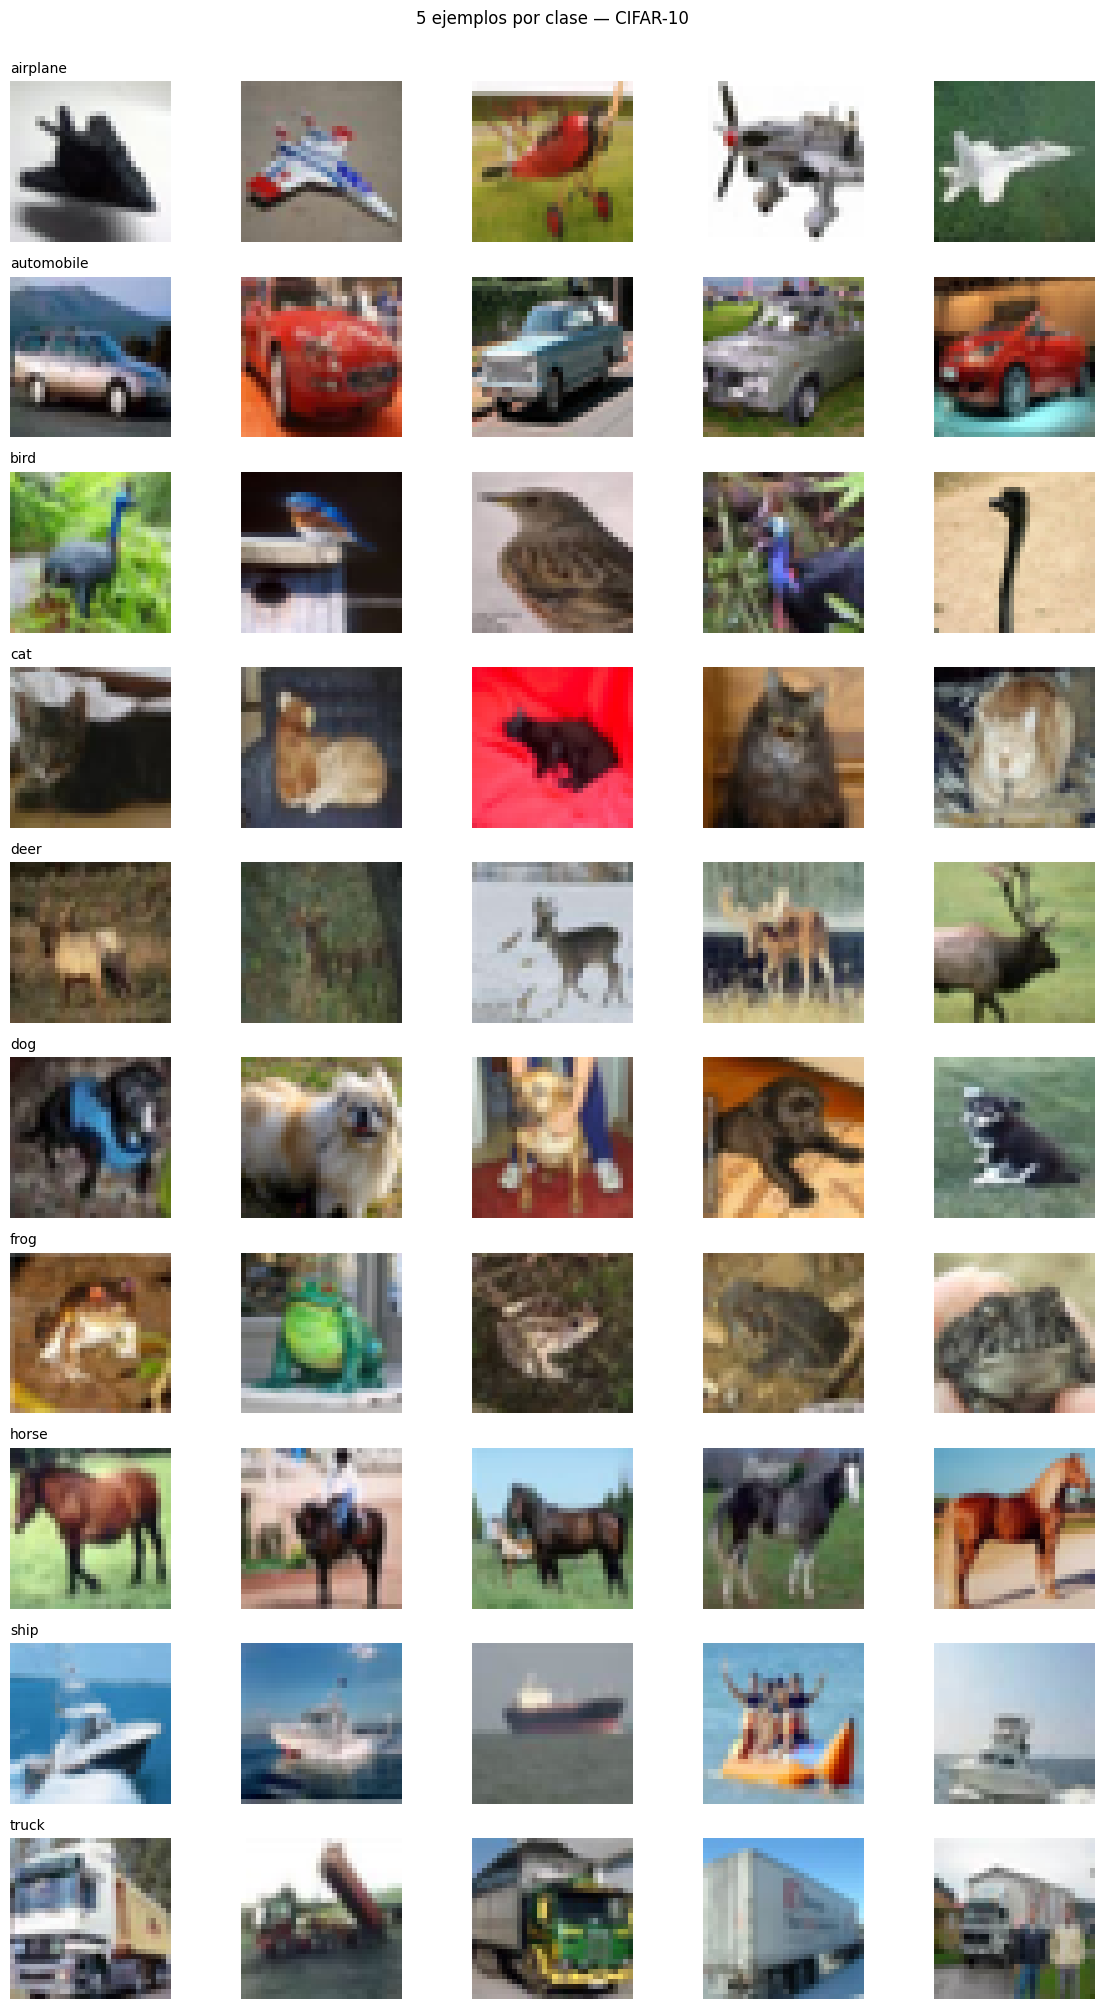

In [6]:

# 2.4 Visualizar 5 ejemplos por clase

examples_per_class = 5
fig, axes = plt.subplots(num_classes, examples_per_class, figsize=(12, 20))
found = {i: 0 for i in range(num_classes)}

for img, label in train_raw:
    if found[label] < examples_per_class:
        ax = axes[label, found[label]]
        ax.imshow(img)
        ax.axis("off")
        if found[label] == 0:
            ax.set_title(class_names[label], loc="left", fontsize=10)
        found[label] += 1

    if all(v >= examples_per_class for v in found.values()):
        break

plt.suptitle("5 ejemplos por clase — CIFAR-10", y=1.002)
plt.tight_layout()
plt.show()



### Pares de clases que podrían ser más difíciles

Antes de entrenar, se espera que puedan aparecer confusiones en:

- `cat` / `dog`;
- `deer` / `horse`;
- `automobile` / `truck`;
- `airplane` / `ship`.

La hipótesis se comprobará con las matrices de confusión finales.



## 3. División estratificada y preprocesamiento

Se separan **45,000 imágenes para train** y **5,000 para validación**, manteniendo el balance por clase. El test oficial queda reservado para la evaluación final.

La augmentation se usa únicamente en entrenamiento. Aplicarla aleatoriamente en validación o test cambiaría las muestras evaluadas y haría menos estable la comparación entre configuraciones.


In [7]:

# 3.1 División estratificada 45,000 / 5,000

all_indices = np.arange(len(train_raw))

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=5000,
    stratify=targets,
    random_state=SEED
)

print("Train:", len(train_idx))
print("Val  :", len(val_idx))
print("Test :", len(test_raw))
print("Balance train:", np.bincount(targets[train_idx], minlength=num_classes))
print("Balance val  :", np.bincount(targets[val_idx], minlength=num_classes))


Train: 45000
Val  : 5000
Test : 10000
Balance train: [4500 4500 4500 4500 4500 4500 4500 4500 4500 4500]
Balance val  : [500 500 500 500 500 500 500 500 500 500]


In [8]:

# 3.2 Transformaciones

cifar_mean_tuple = tuple(cifar_mean.tolist())
cifar_std_tuple = tuple(cifar_std.tolist())

cnn_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean_tuple, cifar_std_tuple),
])

cnn_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean_tuple, cifar_std_tuple),
])

vgg_train_transform = transforms.Compose([
    transforms.Resize((VGG_IMAGE_SIZE, VGG_IMAGE_SIZE)),
    transforms.RandomCrop(VGG_IMAGE_SIZE, padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean.tolist(), imagenet_std.tolist()),
])

vgg_eval_transform = transforms.Compose([
    transforms.Resize((VGG_IMAGE_SIZE, VGG_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean.tolist(), imagenet_std.tolist()),
])

native_pixels = 32 * 32
vgg_pixels = VGG_IMAGE_SIZE * VGG_IMAGE_SIZE

print(f"32x32  -> {native_pixels:,} píxeles")
print(f"{VGG_IMAGE_SIZE}x{VGG_IMAGE_SIZE} -> {vgg_pixels:,} píxeles")
print(f"Factor de aumento en píxeles: {vgg_pixels/native_pixels:.1f}x")


32x32  -> 1,024 píxeles
112x112 -> 12,544 píxeles
Factor de aumento en píxeles: 12.2x


In [9]:

# 3.3 Datasets y DataLoaders

def make_subset_dataset(train, transform, indices=None):
    ds = datasets.CIFAR10(
        root=DATA_DIR,
        train=train,
        download=False,
        transform=transform
    )
    return Subset(ds, indices) if indices is not None else ds

def make_loaders(model_family="cnn", train_indices=None, val_indices=None):
    if model_family == "cnn":
        train_transform = cnn_train_transform
        eval_transform = cnn_eval_transform
        batch_size = BATCH_SIZE_CNN
    else:
        train_transform = vgg_train_transform
        eval_transform = vgg_eval_transform
        batch_size = BATCH_SIZE_VGG

    train_indices = train_idx if train_indices is None else np.array(train_indices)
    val_indices = val_idx if val_indices is None else np.array(val_indices)

    if FAST_DEV_RUN:
        rng = np.random.default_rng(SEED)
        train_indices = rng.choice(train_indices, min(3000, len(train_indices)), replace=False)
        val_indices = rng.choice(val_indices, min(1000, len(val_indices)), replace=False)

    train_ds = make_subset_dataset(True, train_transform, train_indices)
    val_ds = make_subset_dataset(True, eval_transform, val_indices)
    test_ds = datasets.CIFAR10(
        root=DATA_DIR,
        train=False,
        download=False,
        transform=eval_transform
    )

    common = dict(
        batch_size=batch_size,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    train_loader = DataLoader(train_ds, shuffle=True, **common)
    val_loader = DataLoader(val_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)

    return train_loader, val_loader, test_loader



## 4. Investigación breve: PyTorch y transfer learning

- `torchvision.models.vgg16` carga VGG-16.
- `VGG16_Weights.DEFAULT` representa los pesos preentrenados.
- `weights.transforms()` devuelve el preprocesamiento oficial asociado a esos pesos.
- `model.features` contiene los bloques convolucionales.
- `model.avgpool` corresponde a `nn.AdaptiveAvgPool2d`.
- `model.classifier` contiene las capas totalmente conectadas.
- `requires_grad=False` congela parámetros.
- `model.train()` activa el comportamiento de entrenamiento.
- `model.eval()` activa el comportamiento de evaluación.
- `torch.no_grad()` evita construir el grafo de gradientes durante inferencia.
- Los `param_groups` del optimizador permiten usar distintos learning rates para backbone y clasificador.
- `fvcore.nn.FlopCountAnalysis` permite estimar FLOPs.
- `torch.cuda.max_memory_allocated()` reporta memoria pico asignada en GPU.
- `torch.cuda.synchronize()` sincroniza CUDA para medir tiempos correctamente.

### MACs y FLOPs

Un MAC combina una multiplicación y una acumulación. Una convención común aproxima **1 MAC ≈ 2 FLOPs**. La equivalencia depende de la herramienta utilizada.

### Parámetros totales y entrenables

Los parámetros totales incluyen todos los pesos del modelo. Los entrenables son solo aquellos con `requires_grad=True`.


In [10]:

# 4.1 Inspección de VGG-16 y transforms oficiales

weights = VGG16_Weights.DEFAULT
print("Pesos:", weights)
print("Transforms oficiales:")
print(weights.transforms())

tmp_vgg = models.vgg16(weights=weights)
print(tmp_vgg)
del tmp_vgg
gc.collect()


Pesos: VGG16_Weights.IMAGENET1K_V1
Transforms oficiales:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 101MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

3651

## 5. Definición de modelos

In [11]:

# 5.1 CNN propia desde cero con 3 bloques convolucionales

class ScratchCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()

        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 3
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def build_scratch_cnn(dropout=0.4):
    return ScratchCNN(num_classes=num_classes, dropout=dropout)


In [12]:

# 5.2 VGG-16 feature extraction y fine-tuning

# Rangos de las capas correspondientes a cada bloque convolucional de VGG-16.
VGG_BLOCK_RANGES = {
    1: (0, 5),
    2: (5, 10),
    3: (10, 17),
    4: (17, 24),
    5: (24, 31),
}

def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_vgg_blocks(model, blocks):
    for block in blocks:
        start, end = VGG_BLOCK_RANGES[block]
        for layer in model.features[start:end]:
            for p in layer.parameters():
                p.requires_grad = True

def replace_vgg_classifier(model, dropout=0.5):
    model.classifier[2] = nn.Dropout(dropout)
    model.classifier[5] = nn.Dropout(dropout)

    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)
    return model

def build_vgg_feature_extractor(dropout=0.5):
    model = models.vgg16(weights=VGG16_Weights.DEFAULT)

    # Se congelan todos los parámetros.
    freeze_all(model)

    # Se sustituye la última salida por 10 clases.
    model = replace_vgg_classifier(model, dropout)

    # Se entrena el clasificador; features permanece congelado.
    for p in model.classifier.parameters():
        p.requires_grad = True

    return model

def build_vgg_finetune(blocks=(5,), dropout=0.5):
    model = models.vgg16(weights=VGG16_Weights.DEFAULT)
    freeze_all(model)
    model = replace_vgg_classifier(model, dropout)

    for p in model.classifier.parameters():
        p.requires_grad = True

    unfreeze_vgg_blocks(model, blocks)
    return model


In [13]:

# 5.3 Conteo de parámetros

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

check_models = {
    "CNN scratch": build_scratch_cnn(),
    "VGG feature extractor": build_vgg_feature_extractor(),
    "VGG fine-tuning bloque 5": build_vgg_finetune((5,))
}

rows = []
for name, model in check_models.items():
    total, trainable = count_parameters(model)
    rows.append({
        "modelo": name,
        "parametros_totales": total,
        "parametros_entrenables": trainable,
        "porcentaje_entrenable": 100 * trainable / total
    })
    del model
    gc.collect()

display(pd.DataFrame(rows))


,modelo,parametros_totales,parametros_entrenables,porcentaje_entrenable
0,CNN scratch,3249994,3249994,100.000000
1,VGG feature extractor,134301514,119586826,89.043543
2,VGG fine-tuning bloque 5,134301514,126666250,94.314834



## 6. Entrenamiento, evaluación y medición de recursos

La mejor época de cada iteración se selecciona por **F1 macro de validación**.


In [14]:
# 6.1 Métricas

def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    model.eval()

    losses = []
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # AMP acelera inferencia en GPU.
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            logits = model(x)

            if criterion is not None:
                loss = criterion(logits, y)
                losses.append(loss.item())

        pred = logits.argmax(dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

    metrics = classification_metrics(y_true, y_pred)
    metrics["loss"] = float(np.mean(losses)) if losses else np.nan

    return metrics, np.array(y_true), np.array(y_pred)


In [15]:
# 6.2 Entrenamiento de una iteración
# Incluye Automatic Mixed Precision en CUDA para acelerar VGG-16.

def train_one_experiment(
    model,
    train_loader,
    val_loader,
    optimizer,
    epochs,
    experiment_name,
    scheduler=None
):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)

    history = []
    best_f1 = -1
    best_state = None

    # GradScaler solo tiene efecto cuando CUDA/AMP está activo.
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    total_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        epoch_start = time.perf_counter()
        model.train()

        train_losses = []
        train_true, train_pred = [], []

        pbar = tqdm(
            train_loader,
            desc=f"{experiment_name} | epoch {epoch}/{epochs}",
            leave=False
        )

        for x, y in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=USE_AMP
            ):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_losses.append(loss.item())
            pred = logits.argmax(dim=1)

            train_true.extend(y.detach().cpu().numpy())
            train_pred.extend(pred.detach().cpu().numpy())

        if scheduler is not None:
            scheduler.step()

        train_metrics = classification_metrics(train_true, train_pred)
        val_metrics, _, _ = evaluate_model(model, val_loader, criterion)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        epoch_time = time.perf_counter() - epoch_start

        row = {
            "experiment": experiment_name,
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": val_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision_macro": val_metrics["precision_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"{experiment_name} | epoch {epoch:02d} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_acc={row['val_accuracy']:.4f} | "
            f"val_f1={row['val_f1_macro']:.4f} | "
            f"{epoch_time:.1f}s"
        )

        if row["val_f1_macro"] > best_f1:
            best_f1 = row["val_f1_macro"]
            best_state = copy.deepcopy(model.state_dict())

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    total_time = time.perf_counter() - total_start

    peak_memory_mb = (
        torch.cuda.max_memory_allocated() / (1024 ** 2)
        if torch.cuda.is_available()
        else np.nan
    )

    model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["val_f1_macro"].idxmax()]

    return {
        "model": model,
        "history": history_df,
        "best_epoch": int(best_row["epoch"]),
        "best_val_f1": float(best_row["val_f1_macro"]),
        "best_val_accuracy": float(best_row["val_accuracy"]),
        "total_time_sec": float(total_time),
        "avg_epoch_time_sec": float(history_df["epoch_time_sec"].mean()),
        "peak_memory_mb": float(peak_memory_mb) if not np.isnan(peak_memory_mb) else np.nan,
    }


In [16]:

# 6.3 FLOPs y latencia

def estimate_flops(model, input_shape):
    if not FVCORE_AVAILABLE:
        return np.nan

    model_copy = copy.deepcopy(model).to(device).eval()
    x = torch.randn(*input_shape, device=device)

    try:
        with torch.no_grad():
            flops = FlopCountAnalysis(model_copy, x).total()
        return float(flops)
    except Exception as e:
        print("No se pudieron calcular FLOPs:", e)
        return np.nan
    finally:
        del model_copy, x
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

@torch.no_grad()
def measure_inference_latency(model, input_shape, warmup=20, repetitions=100):
    model = model.to(device).eval()
    x = torch.randn(*input_shape, device=device)

    for _ in range(warmup):
        _ = model(x)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    for _ in range(repetitions):
        _ = model(x)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    return elapsed / repetitions * 1000



## 7. Nueve iteraciones

Se realizan **3 configuraciones por estrategia**.  
En fine-tuning se modifica tanto el número de bloques descongelados como los learning rates.


### Ajuste de tiempo de ejecución

Para hacer viable la práctica:
- CNN: 10 epochs por iteración.
- Feature extraction: 5 epochs por iteración.
- Fine-tuning: 5 epochs por iteración.
- VGG-16: 112×112.
- AMP se activa automáticamente si hay GPU CUDA.

Se mantienen las **3 iteraciones por modelo (9 en total)** solicitadas en el laboratorio.


In [17]:

# 7.1 Hiperparámetros

EPOCHS_CNN = 10
EPOCHS_FE = 5
EPOCHS_FT = 5

if FAST_DEV_RUN:
    EPOCHS_CNN = EPOCHS_FE = EPOCHS_FT = 2

experiment_configs = {
    "cnn": [
        {
            "name": "cnn_iter1",
            "lr": 1e-3,
            "weight_decay": 1e-4,
            "dropout": 0.3,
            "epochs": EPOCHS_CNN
        },
        {
            "name": "cnn_iter2",
            "lr": 5e-4,
            "weight_decay": 5e-4,
            "dropout": 0.4,
            "epochs": EPOCHS_CNN
        },
        {
            "name": "cnn_iter3",
            "lr": 3e-4,
            "weight_decay": 1e-4,
            "dropout": 0.5,
            "epochs": EPOCHS_CNN
        },
    ],

    "feature_extractor": [
        {
            "name": "fe_iter1",
            "lr": 1e-3,
            "weight_decay": 1e-4,
            "dropout": 0.4,
            "epochs": EPOCHS_FE
        },
        {
            "name": "fe_iter2",
            "lr": 5e-4,
            "weight_decay": 1e-4,
            "dropout": 0.5,
            "epochs": EPOCHS_FE
        },
        {
            "name": "fe_iter3",
            "lr": 2e-4,
            "weight_decay": 5e-4,
            "dropout": 0.5,
            "epochs": EPOCHS_FE
        },
    ],

    "fine_tuning": [
        {
            "name": "ft_iter1_block5",
            "blocks": (5,),
            "backbone_lr": 1e-5,
            "classifier_lr": 1e-4,
            "weight_decay": 1e-4,
            "dropout": 0.5,
            "epochs": EPOCHS_FT
        },
        {
            "name": "ft_iter2_blocks45",
            "blocks": (4, 5),
            "backbone_lr": 5e-6,
            "classifier_lr": 1e-4,
            "weight_decay": 1e-4,
            "dropout": 0.5,
            "epochs": EPOCHS_FT
        },
        {
            "name": "ft_iter3_block5",
            "blocks": (5,),
            "backbone_lr": 5e-6,
            "classifier_lr": 5e-5,
            "weight_decay": 5e-4,
            "dropout": 0.4,
            "epochs": EPOCHS_FT
        },
    ]
}

experiment_configs


{'cnn': [{'name': 'cnn_iter1',
   'lr': 0.001,
   'weight_decay': 0.0001,
   'dropout': 0.3,
   'epochs': 10},
  {'name': 'cnn_iter2',
   'lr': 0.0005,
   'weight_decay': 0.0005,
   'dropout': 0.4,
   'epochs': 10},
  {'name': 'cnn_iter3',
   'lr': 0.0003,
   'weight_decay': 0.0001,
   'dropout': 0.5,
   'epochs': 10}],
 'feature_extractor': [{'name': 'fe_iter1',
   'lr': 0.001,
   'weight_decay': 0.0001,
   'dropout': 0.4,
   'epochs': 5},
  {'name': 'fe_iter2',
   'lr': 0.0005,
   'weight_decay': 0.0001,
   'dropout': 0.5,
   'epochs': 5},
  {'name': 'fe_iter3',
   'lr': 0.0002,
   'weight_decay': 0.0005,
   'dropout': 0.5,
   'epochs': 5}],
 'fine_tuning': [{'name': 'ft_iter1_block5',
   'blocks': (5,),
   'backbone_lr': 1e-05,
   'classifier_lr': 0.0001,
   'weight_decay': 0.0001,
   'dropout': 0.5,
   'epochs': 5},
  {'name': 'ft_iter2_blocks45',
   'blocks': (4, 5),
   'backbone_lr': 5e-06,
   'classifier_lr': 0.0001,
   'weight_decay': 0.0001,
   'dropout': 0.5,
   'epochs': 5},

In [18]:

# 7.2 Construir modelo + optimizador

def build_experiment(model_type, config):
    if model_type == "cnn":
        model = build_scratch_cnn(config["dropout"])
        optimizer = optim.AdamW(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
        family = "cnn"

    elif model_type == "feature_extractor":
        model = build_vgg_feature_extractor(config["dropout"])

        optimizer = optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
        family = "vgg"

    elif model_type == "fine_tuning":
        model = build_vgg_finetune(
            blocks=config["blocks"],
            dropout=config["dropout"]
        )

        backbone_params = [
            p for p in model.features.parameters()
            if p.requires_grad
        ]
        classifier_params = [
            p for p in model.classifier.parameters()
            if p.requires_grad
        ]

        optimizer = optim.AdamW(
            [
                {
                    "params": backbone_params,
                    "lr": config["backbone_lr"]
                },
                {
                    "params": classifier_params,
                    "lr": config["classifier_lr"]
                }
            ],
            weight_decay=config["weight_decay"]
        )
        family = "vgg"

    else:
        raise ValueError(model_type)

    return model, optimizer, family


In [19]:

# 7.3 Ejecutar las 9 iteraciones

all_runs = {}
summary_rows = []

RUN_TRAINING = True

if RUN_TRAINING:
    for model_type, configs in experiment_configs.items():
        print("\n" + "=" * 80)
        print("MODELO:", model_type)
        print("=" * 80)

        for config in configs:
            set_seed()
            print("\nConfiguración:", config)

            model, optimizer, family = build_experiment(model_type, config)
            train_loader, val_loader, _ = make_loaders(family)

            total_params, trainable_params = count_parameters(model)

            result = train_one_experiment(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                epochs=config["epochs"],
                experiment_name=config["name"]
            )

            result["config"] = copy.deepcopy(config)
            result["model_type"] = model_type
            result["total_params"] = total_params
            result["trainable_params"] = trainable_params

            all_runs[config["name"]] = result

            summary_rows.append({
                "model_type": model_type,
                "experiment": config["name"],
                "best_epoch": result["best_epoch"],
                "best_val_accuracy": result["best_val_accuracy"],
                "best_val_f1_macro": result["best_val_f1"],
                "total_params": total_params,
                "trainable_params": trainable_params,
                "avg_epoch_time_sec": result["avg_epoch_time_sec"],
                "total_time_sec": result["total_time_sec"],
                "peak_memory_mb": result["peak_memory_mb"],
                "config": str(config),
            })

            torch.save(
                result["model"].state_dict(),
                OUTPUT_DIR / f"{config['name']}_best.pt"
            )

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    iterations_df = pd.DataFrame(summary_rows)
    display(iterations_df)
    iterations_df.to_csv(
        OUTPUT_DIR / "iteraciones_validacion.csv",
        index=False
    )



MODELO: cnn

Configuración: {'name': 'cnn_iter1', 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'epochs': 10}


cnn_iter1 | epoch 1/10:   0%|          | 0/352 [00:00<?, ?it/s]

cnn_iter1 | epoch 01 | train_loss=1.7549 | val_loss=1.2914 | val_acc=0.5176 | val_f1=0.5031 | 43.6s


cnn_iter1 | epoch 2/10:   0%|          | 0/352 [00:00<?, ?it/s]

cnn_iter1 | epoch 02 | train_loss=1.2110 | val_loss=1.0556 | val_acc=0.5958 | val_f1=0.5800 | 19.7s


...

ft_iter3_block5 | epoch 4/5:   0%|          | 0/704 [00:00<?, ?it/s]

ft_iter3_block5 | epoch 04 | train_loss=0.2748 | val_loss=0.3020 | val_acc=0.8980 | val_f1=0.8972 | 82.4s


ft_iter3_block5 | epoch 5/5:   0%|          | 0/704 [00:00<?, ?it/s]

ft_iter3_block5 | epoch 05 | train_loss=0.2356 | val_loss=0.3160 | val_acc=0.8966 | val_f1=0.8959 | 82.0s


,model_type,experiment,best_epoch,best_val_accuracy,best_val_f1_macro,total_params,trainable_params,avg_epoch_time_sec,total_time_sec,peak_memory_mb,config
0,cnn,cnn_iter1,9,0.8412,0.840397,3249994,3249994,22.968240,229.727786,669.812012,"{'name': 'cnn_iter1', 'lr': 0.001, 'weight_dec..."
1,cnn,cnn_iter2,10,0.8334,0.830554,3249994,3249994,21.268000,212.728046,263.651855,"{'name': 'cnn_iter2', 'lr': 0.0005, 'weight_de..."
2,cnn,cnn_iter3,10,0.8352,0.834684,3249994,3249994,21.905025,219.087539,290.337402,"{'name': 'cnn_iter3', 'lr': 0.0003, 'weight_de..."
3,feature_extractor,fe_iter1,5,0.8574,0.856212,134301514,119586826,72.777119,363.918271,3003.586426,"{'name': 'fe_iter1', 'lr': 0.001, 'weight_deca..."
4,feature_extractor,fe_iter2,3,0.8538,0.853229,134301514,119586826,73.887202,369.462031,3973.470215,"{'name': 'fe_iter2', 'lr': 0.0005, 'weight_dec..."
5,feature_extractor,fe_iter3,4,0.8646,0.863368,134301514,119586826,73.262978,366.347394,4943.604004,"{'name': 'fe_iter3', 'lr': 0.0002, 'weight_dec..."
6,fine_tuning,ft_iter1_block5,4,0.8988,0.898015,134301514,126666250,82.275151,411.410411,5993.442871,"{'name': 'ft_iter1_block5', 'blocks': (5,), 'b..."
7,fine_tuning,ft_iter2_blocks45,5,0.9162,0.915512,134301514,132566026,95.033805,475.207605,7060.850098,"{'name': 'ft_iter2_blocks45', 'blocks': (4, 5)..."
8,fine_tuning,ft_iter3_block5,4,0.8980,0.897240,134301514,126666250,82.012253,410.093145,8011.540527,"{'name': 'ft_iter3_block5', 'blocks': (5,), 'b..."


## 8. Curvas de pérdida de las 9 iteraciones

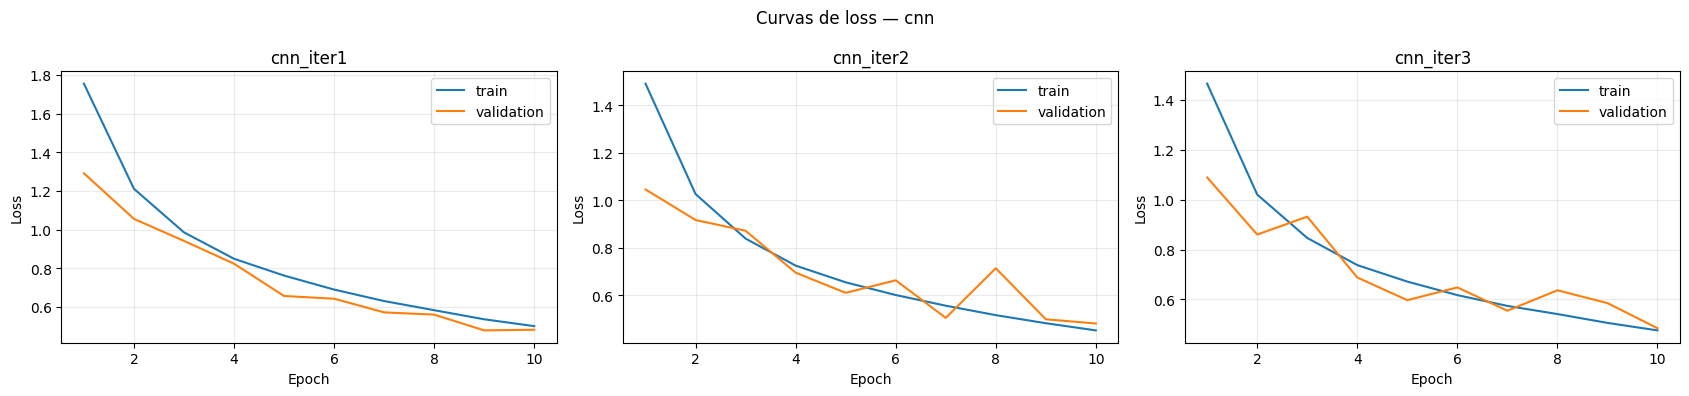

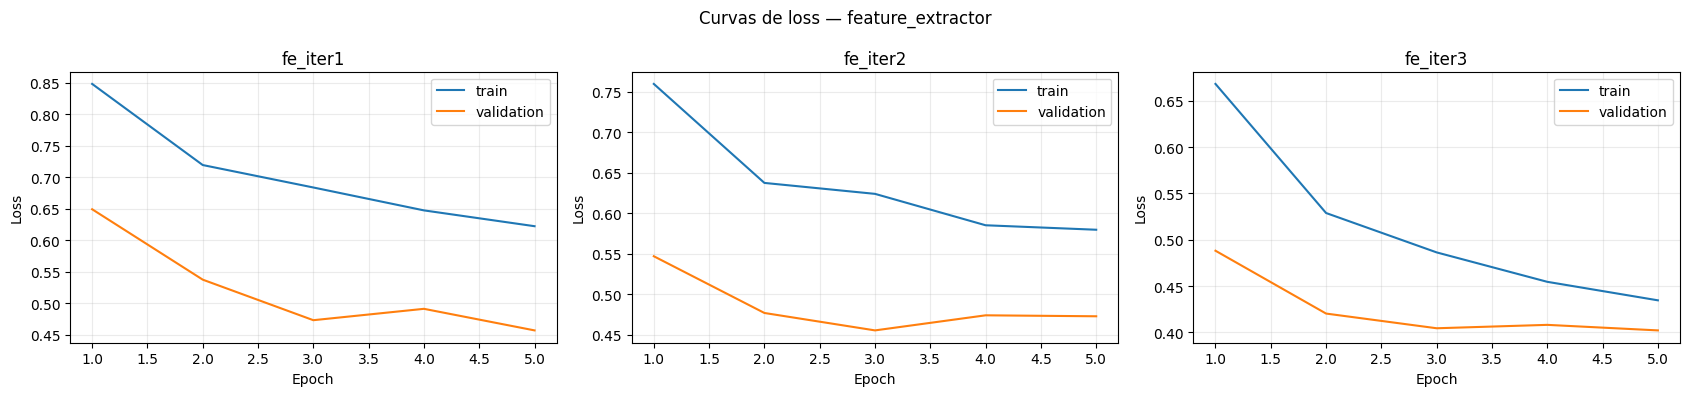

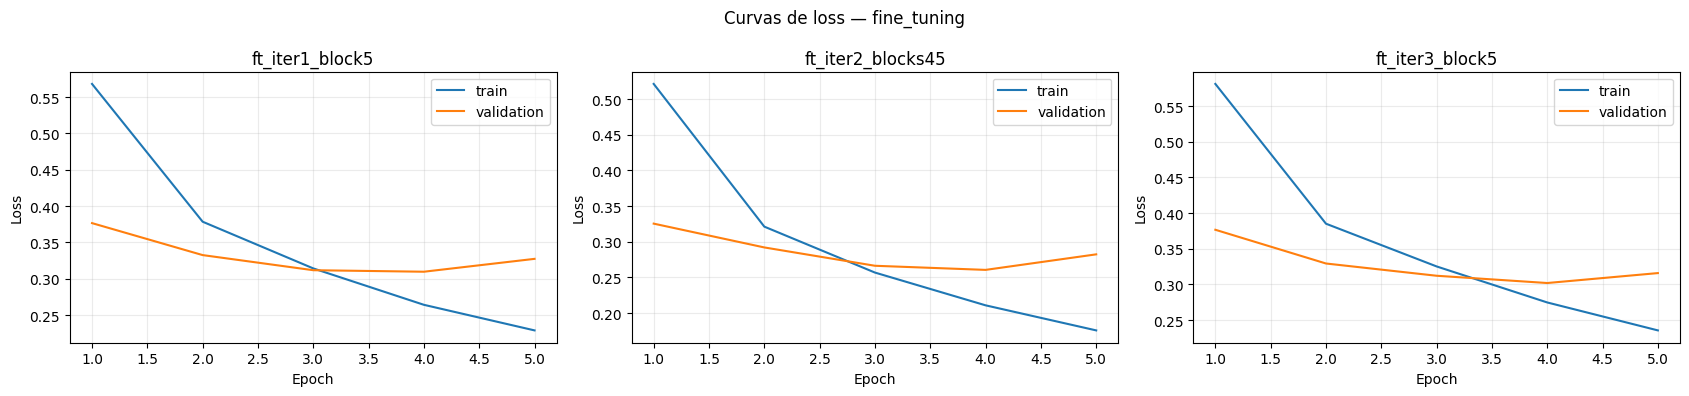

In [20]:

# 8.1 Curvas train/validation loss

def plot_loss_iterations(model_type):
    configs = experiment_configs[model_type]
    fig, axes = plt.subplots(1, len(configs), figsize=(17, 4))

    for ax, config in zip(axes, configs):
        name = config["name"]
        hist = all_runs[name]["history"]

        ax.plot(hist["epoch"], hist["train_loss"], label="train")
        ax.plot(hist["epoch"], hist["val_loss"], label="validation")
        ax.set_title(name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(alpha=0.25)

    plt.suptitle(f"Curvas de loss — {model_type}")
    plt.tight_layout()
    plt.show()

if RUN_TRAINING:
    for model_type in experiment_configs:
        plot_loss_iterations(model_type)



## 9. Selección de la mejor configuración

Se selecciona la mejor configuración de cada estrategia usando **solo validación**, antes de tocar test.


In [21]:

# 9.1 Mejores configuraciones por F1 macro de validación

best_run_names = {}

if RUN_TRAINING:
    for model_type in experiment_configs:
        candidates = [
            (name, data["best_val_f1"])
            for name, data in all_runs.items()
            if data["model_type"] == model_type
        ]

        best_name, best_f1 = max(candidates, key=lambda x: x[1])
        best_run_names[model_type] = best_name

        print(
            f"{model_type}: {best_name} | "
            f"best val F1={best_f1:.4f}"
        )

best_run_names


cnn: cnn_iter1 | best val F1=0.8404
feature_extractor: fe_iter3 | best val F1=0.8634
fine_tuning: ft_iter2_blocks45 | best val F1=0.9155


{'cnn': 'cnn_iter1',
 'feature_extractor': 'fe_iter3',
 'fine_tuning': 'ft_iter2_blocks45'}

In [22]:

# 9.2 Recursos de los mejores modelos

resource_rows = []

if RUN_TRAINING:
    for model_type, run_name in best_run_names.items():
        result = all_runs[run_name]
        model = result["model"]

        if model_type == "cnn":
            input_shape = (1, 3, 32, 32)
        else:
            input_shape = (1, 3, VGG_IMAGE_SIZE, VGG_IMAGE_SIZE)

        flops = estimate_flops(model, input_shape)

        latency_ms = measure_inference_latency(
            model,
            input_shape,
            warmup=10 if FAST_DEV_RUN else 20,
            repetitions=20 if FAST_DEV_RUN else 100
        )

        resource_rows.append({
            "model_type": model_type,
            "experiment": run_name,
            "flops_forward": flops,
            "gflops_forward": flops / 1e9 if not np.isnan(flops) else np.nan,
            "latency_ms_per_image": latency_ms,
            "total_params": result["total_params"],
            "trainable_params": result["trainable_params"],
            "avg_epoch_time_sec": result["avg_epoch_time_sec"],
            "epochs_to_best": result["best_epoch"],
            "total_time_sec": result["total_time_sec"],
            "peak_memory_mb": result["peak_memory_mb"],
        })

    resources_df = pd.DataFrame(resource_rows)
    display(resources_df)

    resources_df.to_csv(
        OUTPUT_DIR / "recursos_mejores_modelos.csv",
        index=False
    )


,model_type,experiment,flops_forward,gflops_forward,latency_ms_per_image,total_params,trainable_params,avg_epoch_time_sec,epochs_to_best,total_time_sec,peak_memory_mb
0,cnn,cnn_iter1,NaN,NaN,0.850520,3249994,3249994,22.968240,9,229.727786,669.812012
1,feature_extractor,fe_iter3,NaN,NaN,4.796748,134301514,119586826,73.262978,4,366.347394,4943.604004
2,fine_tuning,ft_iter2_blocks45,NaN,NaN,4.817753,134301514,132566026,95.033805,5,475.207605,7060.850098


## 10. Evaluación final única sobre el conjunto de test

In [23]:

# 10.1 Métricas de test

test_rows = []
test_predictions = {}

if RUN_TRAINING:
    criterion = nn.CrossEntropyLoss()

    for model_type, run_name in best_run_names.items():
        result = all_runs[run_name]
        model = result["model"]

        family = "cnn" if model_type == "cnn" else "vgg"
        _, _, test_loader = make_loaders(family)

        metrics, y_true, y_pred = evaluate_model(
            model,
            test_loader,
            criterion
        )

        test_predictions[model_type] = (y_true, y_pred)

        test_rows.append({
            "model_type": model_type,
            "experiment": run_name,
            "test_loss": metrics["loss"],
            "test_accuracy": metrics["accuracy"],
            "test_precision_macro": metrics["precision_macro"],
            "test_recall_macro": metrics["recall_macro"],
            "test_f1_macro": metrics["f1_macro"],
        })

    test_df = pd.DataFrame(test_rows)
    display(test_df)

    test_df.to_csv(
        OUTPUT_DIR / "metricas_test_final.csv",
        index=False
    )


,model_type,experiment,test_loss,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,cnn,cnn_iter1,0.500372,0.8324,0.836977,0.8324,0.831940
1,feature_extractor,fe_iter3,0.424493,0.8606,0.861548,0.8606,0.859154
2,fine_tuning,ft_iter2_blocks45,0.293044,0.9113,0.912085,0.9113,0.910650


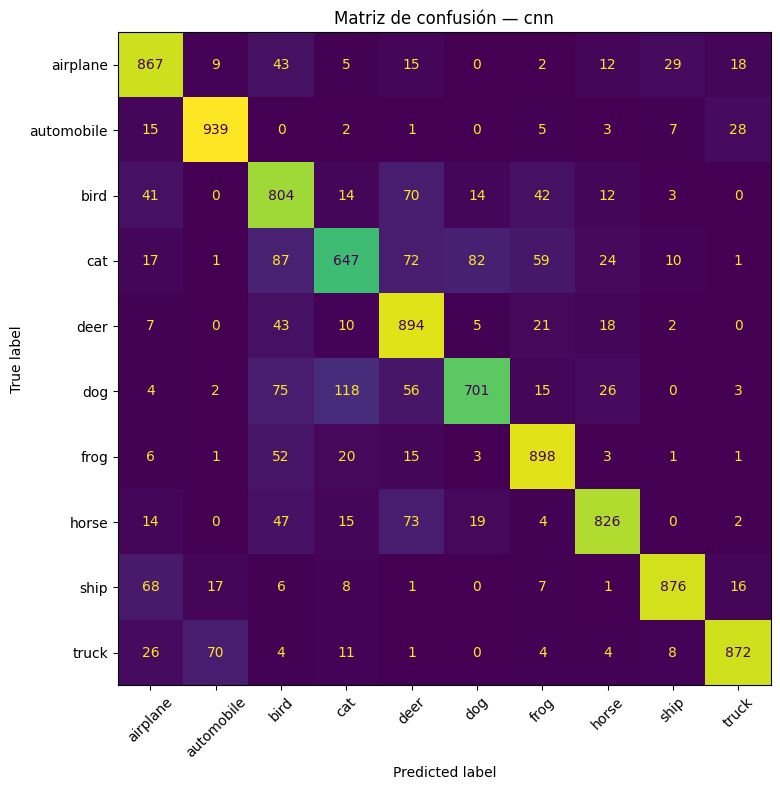

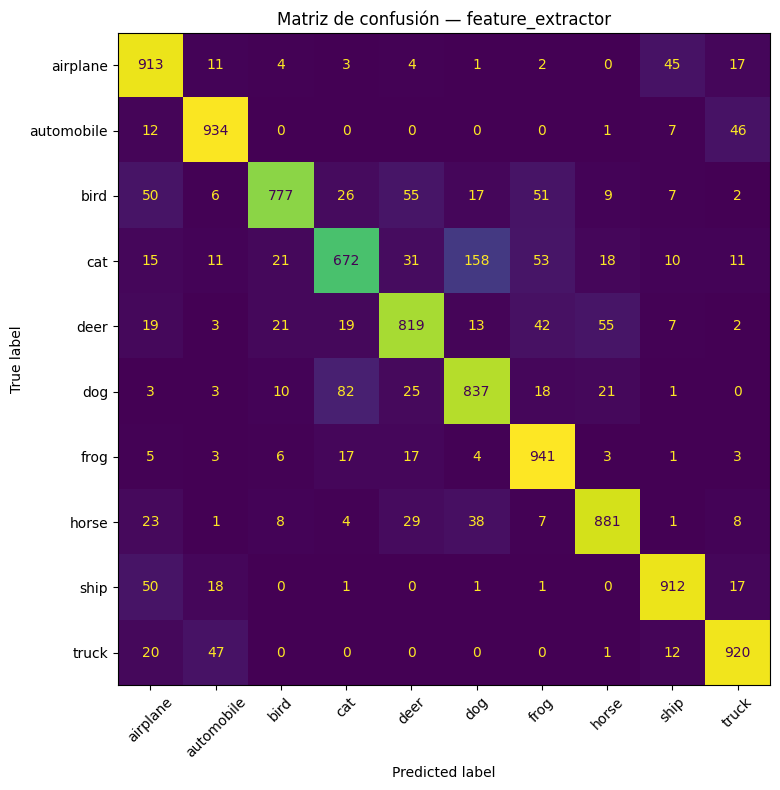

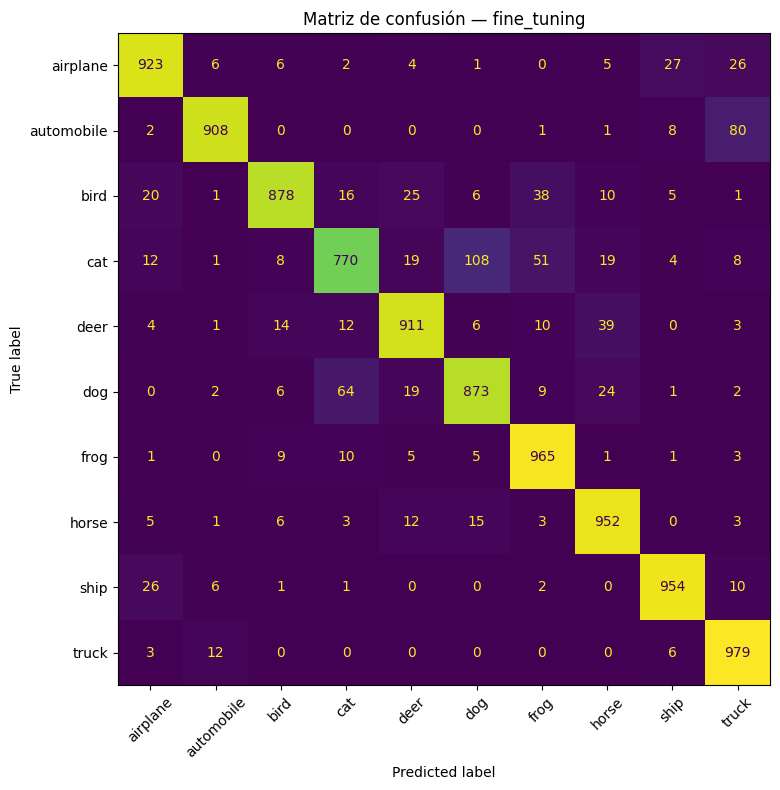

In [24]:

# 10.2 Matrices de confusión

if RUN_TRAINING:
    for model_type, (y_true, y_pred) in test_predictions.items():
        cm = confusion_matrix(y_true, y_pred)

        fig, ax = plt.subplots(figsize=(9, 8))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )
        disp.plot(
            ax=ax,
            xticks_rotation=45,
            values_format="d",
            colorbar=False
        )
        ax.set_title(f"Matriz de confusión — {model_type}")
        plt.tight_layout()
        plt.show()



## 11. Experimento con 10% de los datos

Se mantiene el balance entre clases y se reentrena cada estrategia usando su mejor configuración.


In [25]:

# 11.1 Subconjunto estratificado del 10% del train

train_labels_45k = targets[train_idx]

small_train_idx, _ = train_test_split(
    train_idx,
    train_size=0.10,
    stratify=train_labels_45k,
    random_state=SEED
)

print("Train completo:", len(train_idx))
print("Train 10%:", len(small_train_idx))
print(
    "Distribución 10%:",
    np.bincount(targets[small_train_idx], minlength=num_classes)
)


Train completo: 45000
Train 10%: 4500
Distribución 10%: [450 450 450 450 450 450 450 450 450 450]


In [26]:

# 11.2 Reentrenar las mejores configuraciones con 10%

small_data_rows = {}
small_data_summary = []

if RUN_TRAINING:
    for model_type, best_name in best_run_names.items():
        config = all_runs[best_name]["config"]

        set_seed()
        model, optimizer, family = build_experiment(model_type, config)

        train_loader, val_loader, test_loader = make_loaders(
            family,
            train_indices=small_train_idx,
            val_indices=val_idx
        )

        exp_name = f"{best_name}_10pct"

        result = train_one_experiment(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            epochs=config["epochs"],
            experiment_name=exp_name
        )

        test_metrics, _, _ = evaluate_model(
            result["model"],
            test_loader,
            nn.CrossEntropyLoss()
        )

        small_data_rows[model_type] = result

        small_data_summary.append({
            "model_type": model_type,
            "experiment_10pct": exp_name,
            "best_val_f1_10pct": result["best_val_f1"],
            "test_accuracy_10pct": test_metrics["accuracy"],
            "test_precision_macro_10pct": test_metrics["precision_macro"],
            "test_recall_macro_10pct": test_metrics["recall_macro"],
            "test_f1_macro_10pct": test_metrics["f1_macro"],
            "total_time_sec_10pct": result["total_time_sec"],
            "peak_memory_mb_10pct": result["peak_memory_mb"],
        })

    small_data_df = pd.DataFrame(small_data_summary)
    display(small_data_df)

    small_data_df.to_csv(
        OUTPUT_DIR / "experimento_10pct.csv",
        index=False
    )


cnn_iter1_10pct | epoch 1/10:   0%|          | 0/36 [00:00<?, ?it/s]

cnn_iter1_10pct | epoch 01 | train_loss=2.4390 | val_loss=2.0115 | val_acc=0.2560 | val_f1=0.2117 | 9.9s


cnn_iter1_10pct | epoch 2/10:   0%|          | 0/36 [00:00<?, ?it/s]

cnn_iter1_10pct | epoch 02 | train_loss=1.9002 | val_loss=1.8740 | val_acc=0.2904 | val_f1=0.2552 | 4.4s


cnn_iter1_10pct | epoch 3/10:   0%|          | 0/36 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1684a0b240>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1684a0b240>self._shutdown_workers()
Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'

AssertionError  File "/usr/lib/python3.13/multiprocessing/proce

ft_iter2_blocks45_10pct | epoch 04 | train_loss=0.3149 | val_loss=0.4398 | val_acc=0.8520 | val_f1=0.8501 | 14.8s


ft_iter2_blocks45_10pct | epoch 5/5:   0%|          | 0/71 [00:00<?, ?it/s]

ft_iter2_blocks45_10pct | epoch 05 | train_loss=0.2573 | val_loss=0.4168 | val_acc=0.8628 | val_f1=0.8618 | 14.9s


,model_type,experiment_10pct,best_val_f1_10pct,test_accuracy_10pct,test_precision_macro_10pct,test_recall_macro_10pct,test_f1_macro_10pct,total_time_sec_10pct,peak_memory_mb_10pct
0,cnn,cnn_iter1_10pct,0.535268,0.5497,0.546688,0.5497,0.540880,57.630320,7202.798828
1,feature_extractor,fe_iter3_10pct,0.823886,0.8167,0.822918,0.8167,0.814256,60.590251,9918.485840
2,fine_tuning,ft_iter2_blocks45_10pct,0.861811,0.8575,0.857687,0.8575,0.856546,82.529746,11039.701660


## 12. Tabla comparativa de rendimiento y recursos

In [27]:

# 12.1 Estimación del cómputo total de entrenamiento

# Aproximación:
# entrenamiento completo de una capa ~= forward + backward
# backward se aproxima como ~2x el forward.
#
# Para CNN completa y fine-tuning se usa multiplicador 3.
# Para feature extractor se usa una aproximación menor porque el
# backbone congelado no realiza backward.

def training_flop_multiplier(model_type):
    return 1.5 if model_type == "feature_extractor" else 3.0

if RUN_TRAINING:
    comparison_df = (
        resources_df
        .merge(test_df, on=["model_type", "experiment"], how="left")
        .merge(small_data_df, on="model_type", how="left")
    )

    n_train_images = len(train_idx)

    comparison_df["estimated_training_flops"] = comparison_df.apply(
        lambda row: (
            row["flops_forward"]
            * n_train_images
            * row["epochs_to_best"]
            * training_flop_multiplier(row["model_type"])
            if not pd.isna(row["flops_forward"])
            else np.nan
        ),
        axis=1
    )

    comparison_df["estimated_training_tflops"] = (
        comparison_df["estimated_training_flops"] / 1e12
    )

    display(comparison_df)

    comparison_df.to_csv(
        OUTPUT_DIR / "tabla_comparativa_final.csv",
        index=False
    )


,model_type,experiment,flops_forward,gflops_forward,latency_ms_per_image,total_params,trainable_params,avg_epoch_time_sec,epochs_to_best,total_time_sec,...,experiment_10pct,best_val_f1_10pct,test_accuracy_10pct,test_precision_macro_10pct,test_recall_macro_10pct,test_f1_macro_10pct,total_time_sec_10pct,peak_memory_mb_10pct,estimated_training_flops,estimated_training_tflops
0,cnn,cnn_iter1,NaN,NaN,0.850520,3249994,3249994,22.968240,9,229.727786,...,cnn_iter1_10pct,0.535268,0.5497,0.546688,0.5497,0.540880,57.630320,7202.798828,NaN,NaN
1,feature_extractor,fe_iter3,NaN,NaN,4.796748,134301514,119586826,73.262978,4,366.347394,...,fe_iter3_10pct,0.823886,0.8167,0.822918,0.8167,0.814256,60.590251,9918.485840,NaN,NaN
2,fine_tuning,ft_iter2_blocks45,NaN,NaN,4.817753,134301514,132566026,95.033805,5,475.207605,...,ft_iter2_blocks45_10pct,0.861811,0.8575,0.857687,0.8575,0.856546,82.529746,11039.701660,NaN,NaN


## 13. Gráficas comparativas requeridas

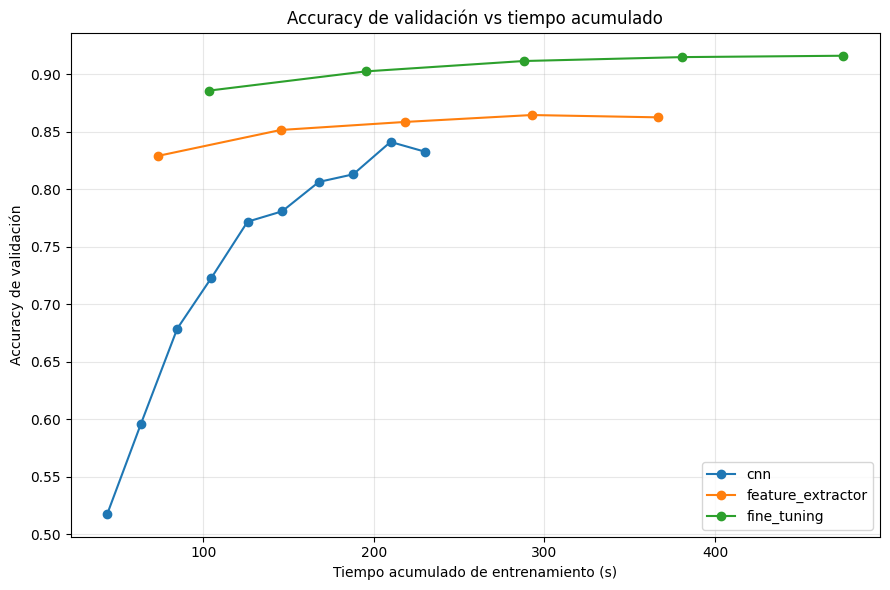

In [28]:

# 13.1 Accuracy de validación vs tiempo acumulado

if RUN_TRAINING:
    plt.figure(figsize=(9, 6))

    for model_type, run_name in best_run_names.items():
        hist = all_runs[run_name]["history"].copy()
        hist["cumulative_time_sec"] = hist["epoch_time_sec"].cumsum()

        plt.plot(
            hist["cumulative_time_sec"],
            hist["val_accuracy"],
            marker="o",
            label=model_type
        )

    plt.xlabel("Tiempo acumulado de entrenamiento (s)")
    plt.ylabel("Accuracy de validación")
    plt.title("Accuracy de validación vs tiempo acumulado")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


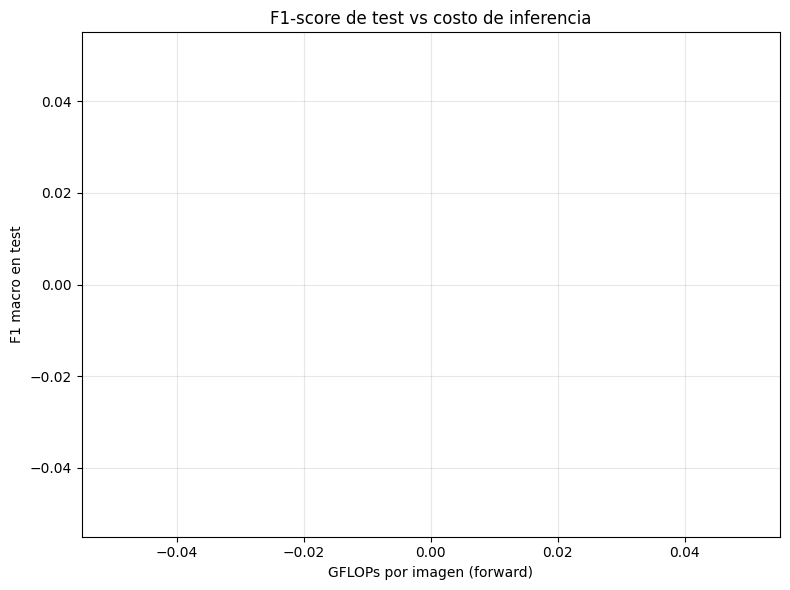

In [29]:

# 13.2 F1 test vs costo computacional

if RUN_TRAINING:
    plt.figure(figsize=(8, 6))

    for _, row in comparison_df.iterrows():
        plt.scatter(
            row["gflops_forward"],
            row["test_f1_macro"],
            s=100
        )
        plt.annotate(
            row["model_type"],
            (row["gflops_forward"], row["test_f1_macro"]),
            xytext=(6, 6),
            textcoords="offset points"
        )

    plt.xlabel("GFLOPs por imagen (forward)")
    plt.ylabel("F1 macro en test")
    plt.title("F1-score de test vs costo de inferencia")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 14. Hardware utilizado

In [30]:

# 14.1 Hardware y software

hardware_info = {
    "device": str(device),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No disponible",
    "cpu": platform.processor() or platform.machine(),
    "platform": platform.platform(),
    "python": platform.python_version(),
    "pytorch": torch.__version__,
}

display(pd.DataFrame([hardware_info]))


,device,gpu,cpu,platform,python,pytorch
0,cuda,Tesla T4,x86_64,Linux-6.6.122+-x86_64-with-glibc2.39,3.13.15,2.11.0+cu128



## 15. Guía para el análisis posterior

Con el notebook ya ejecutado, el informe debe responder directamente desde los resultados obtenidos:

1. cuál modelo obtuvo mayor desempeño en test;
2. magnitud de la diferencia entre modelos;
3. si esa diferencia compensa parámetros, FLOPs, tiempo y memoria;
4. qué modelo presenta mejor relación desempeño/recursos;
5. por qué VGG-16 conserva utilidad al redimensionar CIFAR-10;
6. efecto de descongelar bloque 5 vs. bloques 4 y 5;
7. efecto del learning rate del backbone;
8. señales de overfitting o catastrophic forgetting;
9. cuánto cae cada modelo usando 10% de los datos;
10. pares de clases más confundidos según las matrices;
11. alternativa para móvil, por ejemplo MobileNetV3 o EfficientNet-B0.

Los CSV producidos en `resultados_lab6/` permiten construir las tablas del reporte.


In [31]:

# 15.1 Archivos generados

print("Directorio de resultados:", OUTPUT_DIR.resolve())

for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)


Directorio de resultados: /content/resultados_lab6
- cnn_iter1_best.pt
- cnn_iter2_best.pt
- cnn_iter3_best.pt
- experimento_10pct.csv
- fe_iter1_best.pt
- fe_iter2_best.pt
- fe_iter3_best.pt
- ft_iter1_block5_best.pt
- ft_iter2_blocks45_best.pt
- ft_iter3_block5_best.pt
- iteraciones_validacion.csv
- metricas_test_final.csv
- recursos_mejores_modelos.csv
- tabla_comparativa_final.csv
